# DEM Conditioning: Acquisition and Patch Extraction (Phase 2, Candidate 1)

Implements candidate #1 from `PHASE2_ARCHITECTURE_CANDIDATES.md`: feed an
independent, coarse Digital Elevation Model as an additional conditioning
input alongside Sentinel-1 -- coarse enough (10m here) that it is not
circular with the 1m LiDAR target.

**Why this is worth doing now, despite the doc's original "maybe not
needed" conclusion**: that conclusion was based on `pcrtc/06`'s ZNCC=0.519,
which we now know was computed against the leakage-contaminated
checkpoint. The corrected number (`pcrtc/09`) is ZNCC=0.2344 -- the gap to
Tessa's Sentinel-2 reference (~0.74-0.78) is back to roughly its original
size (~3.2-3.3x), not the ~1.4-1.5x the stale number suggested. This
re-opens the case for DEM conditioning as a targeted fix for the one
metric (ZNCC, spatial pattern fidelity) that has stayed weak across every
experiment in this project so far.

**Data source: ArcticDEM, not Copernicus GLO-30.** Copernicus GLO-30 was
tried first and ruled out with direct evidence, not assumption: the
Tuktoyaktuk AOI sits entirely inside a genuine coverage void in that
product (confirmed by reading the raw source tile directly -- 100% zero
across a 108x112 pixel neighborhood, with real data confined to a
different latitude band of the same tile, most likely a TanDEM-X
interferometric-coherence gap over this low-relief coastal/permafrost
terrain). ArcticDEM (Polar Geospatial Center, stereo-optical-derived, not
radar interferometry) was checked the same way and found to have full,
genuine coverage here -- verified via `stac.pgc.umn.edu`, collection
`arcticdem-mosaics-v4.1-10m`, before committing to building anything on
top of it.

**Mechanism**: `AttrAwareSpatialPool` (the module that fuses Sentinel-1
views) is hard-coded to expect exactly 4 channels and a per-view attrs
vector per view (`cond_img.view(B, k, 4, H, W)`) -- a static DEM has
neither temporal views nor per-view attributes, so it cannot be shoehorned
into that pathway. DEM conditioning instead adds a **separate, additional
conditioning branch**: a small encoder for the DEM raster, concatenated
alongside the SAR-fused features right before the U-Net's `input_conv` --
see `03_dem_conditioning_train.ipynb` for the model change. This notebook
only handles acquiring and collocating the DEM data itself.

**This notebook does not execute automatically. Run cells top to bottom.**

## Setup

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import transform_bounds, reproject, Resampling, calculate_default_transform
from rasterio.merge import merge as rio_merge
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

import pystac_client
import planetary_computer
from dotenv import load_dotenv
from shapely.geometry import box as shapely_box, shape
from shapely.ops import unary_union
from concurrent.futures import ThreadPoolExecutor, as_completed

load_dotenv()
if os.environ.get('PC_SDK_SUBSCRIPTION_KEY'):
    planetary_computer.settings.set_subscription_key(os.environ['PC_SDK_SUBSCRIPTION_KEY'])


## Paths and configuration

Reuses the same Tuktoyaktuk LiDAR/S1 patch set `pcrtc/09` trained on, so
the DEM patches this notebook produces line up exactly with the existing
training data -- same `paired_ids`, same spatial-block split (computed
fresh in the training notebook, not here).

In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
REGION = 'tuk'
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
DEM_DIR = WORKING_REPO / 'input_data' / 'dem_patches_tuk'
DEM_DIR.mkdir(parents=True, exist_ok=True)

PGC_STAC_URL = 'https://stac.pgc.umn.edu/api/v1/'
DEM_COLLECTION = 'arcticdem-mosaics-v4.1-10m'  # verified real coverage for this AOI; Copernicus GLO-30 does not (see intro cell)


## Build the AOI from existing LiDAR patches, and search for DEM coverage

Same `aoi_from_lidar_patches` helper used in `pcrtc/13`. DEM products are
static (no acquisition-date matching needed, unlike Sentinel-1/2), so this
is a single search, not a time-windowed one. Uses PGC's own STAC API
(`stac.pgc.umn.edu`), not Planetary Computer -- ArcticDEM is not on
Planetary Computer's catalog (checked directly, nothing found searching
for "arctic" across all collections).

In [3]:
def aoi_from_lidar_patches(patches_dir, max_files=300, workers=8):
    from rasterio.warp import transform_geom
    paths = sorted(patches_dir.glob('lidar_patch_*.tif'))
    if len(paths) > max_files:
        stride = len(paths) / max_files
        paths = [paths[int(i * stride)] for i in range(max_files)]
    def read_bounds(path):
        with rasterio.open(path) as src:
            return src.crs, src.bounds
    results = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = [pool.submit(read_bounds, p) for p in paths]
        for future in as_completed(futures):
            results.append(future.result())
    crs = results[0][0]
    native = unary_union([shapely_box(*bounds) for _, bounds in results])
    geojson = transform_geom(crs, 'EPSG:4326', native.__geo_interface__)
    return shape(geojson).buffer(0)

aoi = aoi_from_lidar_patches(LIDAR_DIR)
aoi_ll = aoi.convex_hull
print(f'AOI bounds (WGS84): {aoi_ll.bounds}')

# ArcticDEM: PGC's own STAC API, no Planetary Computer signing needed -- confirmed
# via stac.pgc.umn.edu docs that these are open, unsigned HTTP URLs.
catalog = pystac_client.Client.open(PGC_STAC_URL)
dem_search = catalog.search(collections=[DEM_COLLECTION], bbox=list(aoi_ll.bounds))
dem_items = list(dem_search.items())
print(f'DEM tiles found covering the AOI: {len(dem_items)}')
assert dem_items, f'No {DEM_COLLECTION} coverage found for this AOI -- check the collection ID and AOI before continuing.'
for item in dem_items:
    print(' ', item.id)


AOI bounds (WGS84): (-133.36095441893116, 69.69849720309567, -133.27492950651194, 69.85188928067103)
DEM tiles found covering the AOI: 1
  40_18_10m_v4.1


## Mosaic DEM tiles into one array

ArcticDEM mosaic tiles can also span more than one tile per AOI, same
reasoning as before. Verified nodata handling this time (unlike Copernicus
GLO-30, which reported `nodata: None` despite having real void regions):
ArcticDEM tiles report a genuine `-9999.0` nodata value, confirmed via
the earlier coverage check -- passed to `rio_merge` explicitly so void
areas (if any exist elsewhere in this tile) are correctly excluded rather
than silently treated as valid.

In [4]:
dem_srcs = [rasterio.open(item.assets['dem'].href) for item in dem_items]
dem_nodata = dem_srcs[0].nodata
print(f'Source tile nodata value: {dem_nodata}')
dem_mosaic, dem_transform = rio_merge(dem_srcs, nodata=dem_nodata)
dem_crs = dem_srcs[0].crs
for src in dem_srcs:
    src.close()

valid = dem_mosaic[0][dem_mosaic[0] != dem_nodata]
print(f'Mosaic shape: {dem_mosaic.shape}, CRS: {dem_crs}')
print(f'Fraction valid (not nodata): {float((dem_mosaic[0] != dem_nodata).mean()):.4f}')
print(f'Elevation range in mosaic (valid pixels only): {float(valid.min()):.1f} to {float(valid.max()):.1f} m')


Source tile nodata value: -9999.0
Mosaic shape: (1, 10020, 10020), CRS: EPSG:3413
Fraction valid (not nodata): 0.9995
Elevation range in mosaic (valid pixels only): -9.2 to 103.9 m


## Per-patch extraction onto each LiDAR patch's exact grid

Same principle already established (and debugged) three times now in this
project (Sentinel-1's `pcrtc/11`/`ew/01`, and this notebook's own first
attempt with Copernicus GLO-30): the destination grid must be computed
from each **individual patch's** own bounds/CRS/shape, not derived from
the source mosaic's size. `src_nodata` is now set to the DEM's real
`-9999.0` sentinel (not an assumed `NaN`, which was itself never the
actual bug last time, but is worth getting right regardless) -- the
destination is still filled with `NaN` for any pixel with no source
coverage, consistent with every other nodata convention used throughout
this project.

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
print(f'Paired LiDAR/S1 patches to extract DEM for: {len(paired_ids)}')

matched, skipped_nan = 0, []
for pid in paired_ids:
    lidar_path = LIDAR_DIR / f'lidar_patch_{pid}.tif'
    with rasterio.open(lidar_path) as lsrc:
        dst_crs = lsrc.crs
        dst_transform = lsrc.transform
        out_h, out_w = lsrc.height, lsrc.width

    dst = np.full((out_h, out_w), np.nan, dtype=np.float32)
    reproject(
        source=dem_mosaic[0],
        destination=dst,
        src_transform=dem_transform,
        src_crs=dem_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=dem_nodata,
        dst_nodata=np.nan,
    )

    finite_frac = float(np.isfinite(dst).mean())
    if finite_frac < 0.99:
        skipped_nan.append((pid, finite_frac))
        continue

    out_path = DEM_DIR / f'dem_patch_{pid}.tif'
    meta = {
        'driver': 'GTiff', 'count': 1, 'height': out_h, 'width': out_w,
        'dtype': 'float32', 'crs': dst_crs, 'transform': dst_transform, 'nodata': np.nan,
    }
    with rasterio.open(out_path, 'w', **meta) as dst_file:
        dst_file.write(dst, 1)
    matched += 1

print(f'DEM patches written: {matched} / {len(paired_ids)}')
print(f'Skipped (finite_frac < 0.99): {len(skipped_nan)}')
if skipped_nan:
    print('First few skipped:', skipped_nan[:5])


Paired LiDAR/S1 patches to extract DEM for: 1676
DEM patches written: 1676 / 1676
Skipped (finite_frac < 0.99): 0


## Verification

Same sanity-check pattern used throughout this project: confirm coverage
and a plausible value range before trusting the data, rather than
assuming the extraction worked.

In [6]:
dem_paths = sorted(DEM_DIR.glob('dem_patch_*.tif'))
print(f'Total DEM patches on disk: {len(dem_paths)}')

sample_stats = []
for p in dem_paths[:50]:
    with rasterio.open(p) as src:
        arr = src.read(1)
    sample_stats.append({
        'patch_id': p.stem.split('_')[-1],
        'finite_frac': float(np.isfinite(arr).mean()),
        'min_m': float(np.nanmin(arr)),
        'max_m': float(np.nanmax(arr)),
        'mean_m': float(np.nanmean(arr)),
    })

print(f"Mean finite_frac (first 50): {np.mean([s['finite_frac'] for s in sample_stats]):.4f}")
print(f"Elevation range across sample: {min(s['min_m'] for s in sample_stats):.1f} to {max(s['max_m'] for s in sample_stats):.1f} m")
print(f"Mean elevation across sample: {np.mean([s['mean_m'] for s in sample_stats]):.1f} m")


Total DEM patches on disk: 1676
Mean finite_frac (first 50): 1.0000
Elevation range across sample: -6.7 to -6.4 m
Mean elevation across sample: -6.5 m


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_dem_patch_check.png


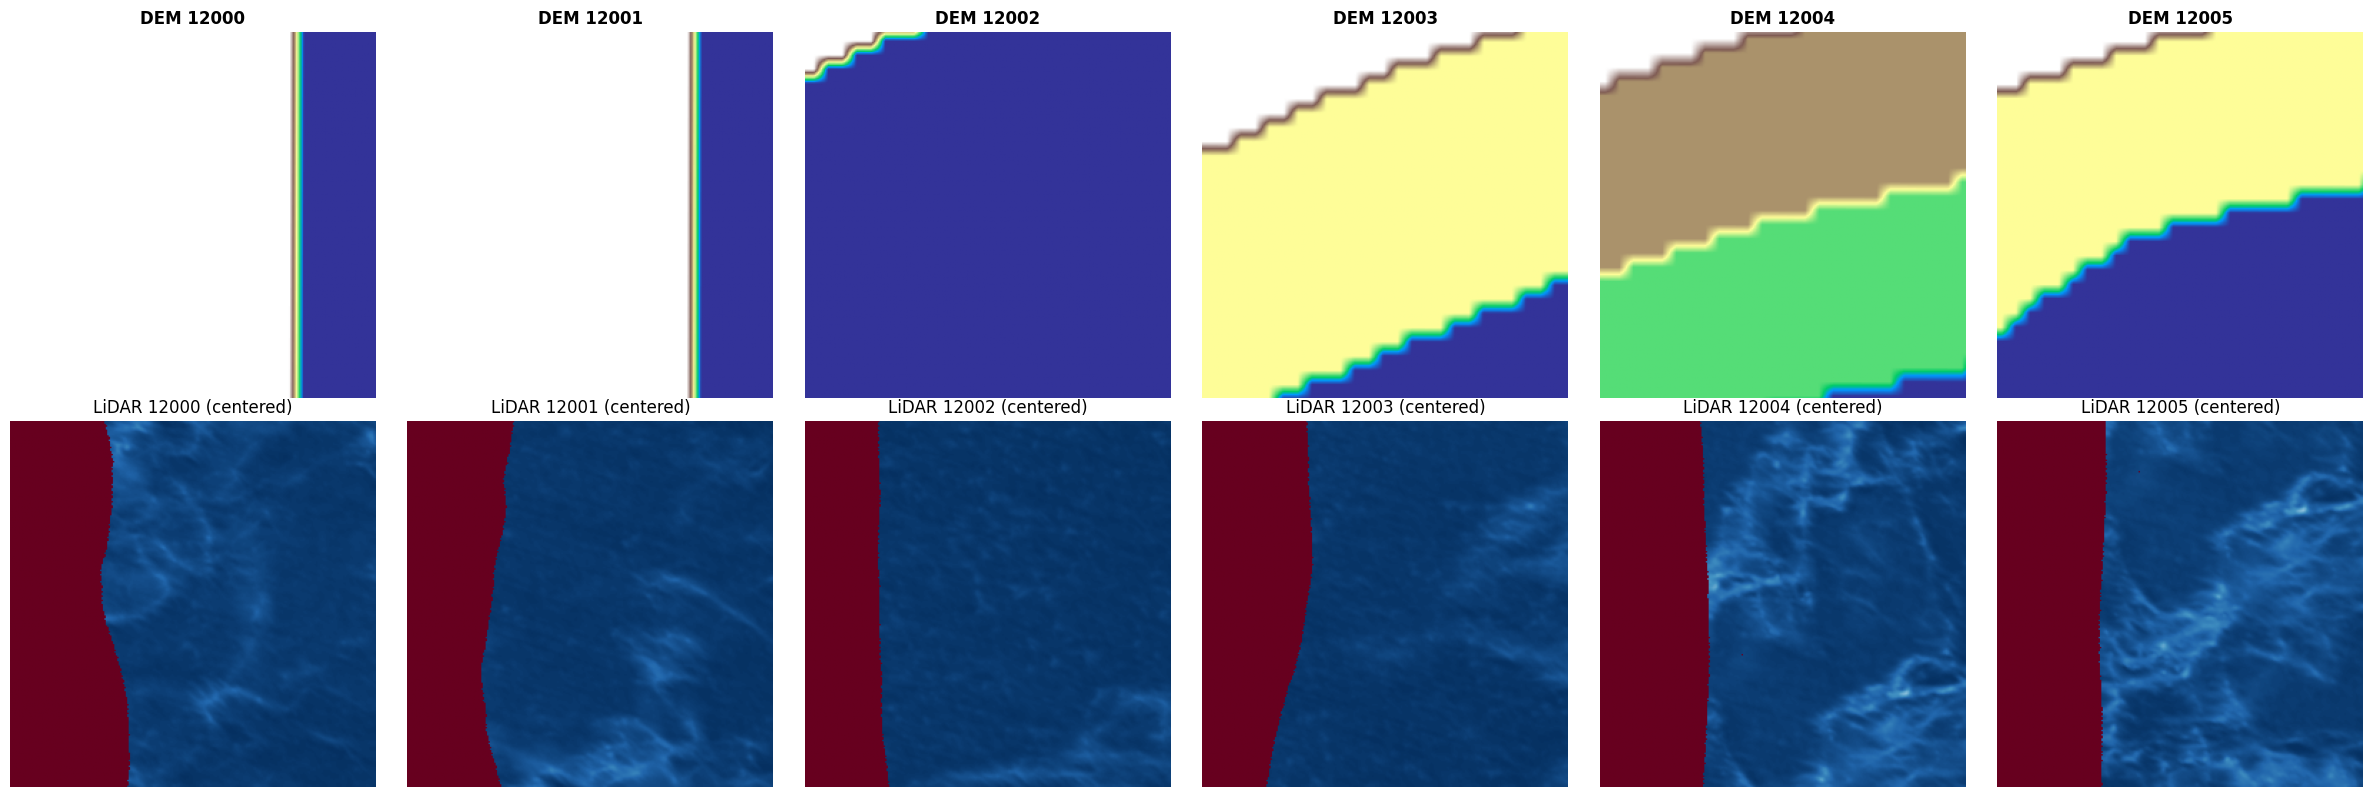

In [7]:
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for col, p in enumerate(dem_paths[:n_show]):
    pid = p.stem.split('_')[-1]
    with rasterio.open(p) as src:
        dem_arr = src.read(1)
    with rasterio.open(LIDAR_DIR / f'lidar_patch_{pid}.tif') as src:
        lidar_raw = src.read()
    lidar_arr = lidar_raw[0]
    lidar_mask = (lidar_raw[1] > 0.5) if lidar_raw.shape[0] > 1 else np.isfinite(lidar_arr)

    axes[0, col].imshow(dem_arr, cmap='terrain')
    axes[0, col].set_title(f'DEM {pid}', fontweight='bold')
    axes[0, col].axis('off')
    axes[1, col].imshow(lidar_arr - lidar_arr[lidar_mask].mean(), cmap='RdBu_r')
    axes[1, col].set_title(f'LiDAR {pid} (centered)')
    axes[1, col].axis('off')

plt.tight_layout()
out_path = WORKING_REPO / 's1_training_outputs' / 's1_pcrtc_dem_patch_check.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print('Saved:', out_path)
plt.show()
